# Uczenie nadzorowane - predykcja

## Wstęp

Projekt miał na celu zastosowanie i porównanie nadzorowanych technik uczenia maszynowego – Regresji Liniowej oraz zaawansowanego modelu ensemble XGBoost – do rozwiązania klasycznego problemu regresji cenowej na historycznym zbiorze danych Boston Housing Dataset. Analiza koncentruje się na przewidywaniu mediany wartości domów (MEDV) na podstawie 13 cech opisujących okolicę. Kluczowym etapem pracy była rygorystyczna selekcja i redukcja cech mająca na celu minimalizację redundancji (współliniowości) i poprawę stabilności modeli, co jednocześnie pozwoliło na dogłębną weryfikację założeń teoretycznych Regresji Liniowej.  
  
## Cel projektu

Głównym celem projektu było skonstruowanie, optymalizacja i porównanie modeli regresji w celu znalezienia najlepszego predyktora cen domów.

Cele szczegółowe obejmują:  
- Redukcję wymiarowości poprzez eliminację cech słabo skorelowanych (|r| < 0.45) oraz redundantnych (analiza VIF i korelacji parami).  
- Optymalizację hiperparametrów modelu XGBoost przy użyciu metody GridSearchCV z metryką R2.  
- Weryfikację założeń modelu Regresji Liniowej oraz ocenę, czy naruszenia tych założeń wpływają na wydajność.  
- Ostateczną ewaluację wszystkich modeli (Regresja Liniowa, XGBoost bazowy i XGBoost optymalny) na zbiorze testowym za pomocą metryk R2, MSE i MAE w celu wyboru najlepszego modelu predykcyjnego.

## 1. Pobranie danych i przygotowanie środowiska

In [254]:
# Wymagane biblioteki
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Pobranie danych z Boston Housing Dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/housing/housing.data"
names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
dataset = pd.read_csv(url, delim_whitespace=True, names=names)

print("\nDane załadowane pomyślnie. Pierwsze 5 wierszy:")
print(dataset.head())
print("\n")

/tmp/ipython-input-2469585452.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataset = pd.read_csv(url, delim_whitespace=True, names=names)



Dane załadowane pomyślnie. Pierwsze 5 wierszy:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  




Boston Housing Dataset to popularny zbiór danych stosowany w dziedzinie uczenia maszynowego do zadań regresji. Zbiór ten zawiera informacje na temat cen domów w różnych dzielnicach miasta Boston w latach 70-tych.

Zmienna docelowa (target):  
MEDV -	Mediana wartości domów  

Zmienne objaśniające - cechy (atrybuty) w zbiorze danych:  
CRIM	- Wskaźnik przestępczości na mieszkańca  
ZN -	Udział terenów pod zabudowę mieszkaniową  
INDUS	- Udział akrów niehandlowych (przemysłowych)  
CHAS	- Graniczenie z rzeką Charles. Binarna	Zmienna fikcyjna (dummy variable). Wartość 1, jeśli obszar graniczy z rzeką, 0 w przeciwnym razie  
NOX -	Stężenie tlenków azotu (wskaźnik zanieczyszczenia powietrza)  
RM -	Średnia liczba pokoi
AGE -	Udział starych budynków  
DIS	- Ważone odległości od centrów zatrudnienia   
RAD	- Indeks dostępności do dróg radialnych  
TAX	- Pełna wartość podatku od nieruchomości   
PTRATIO	- Stosunek uczniów do nauczycieli  
B	- Indeks demograficzny (związany z populacją afroamerykańską)  
LSTAT	- Procent osób o statusie niższej klasy.


## 2. Exploratory Data Analysis (EDA)

### Wstępna analiza

Kształt danych:
(506, 14)


Braki danych:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


Podstawowe informacje o zbiorze danych:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: 

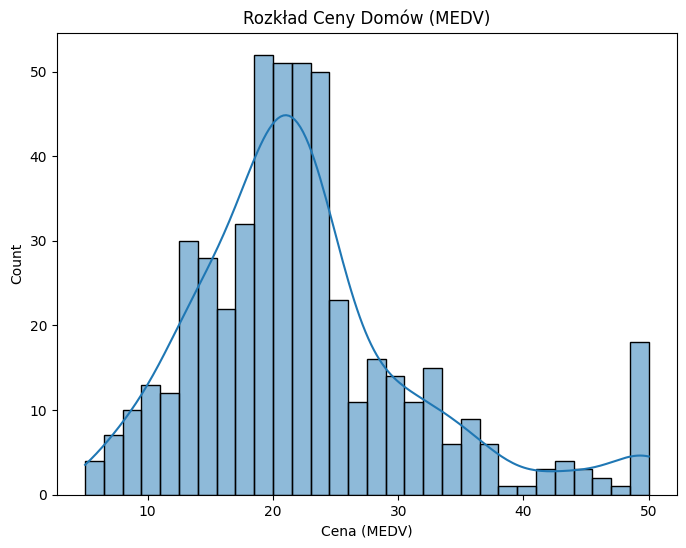

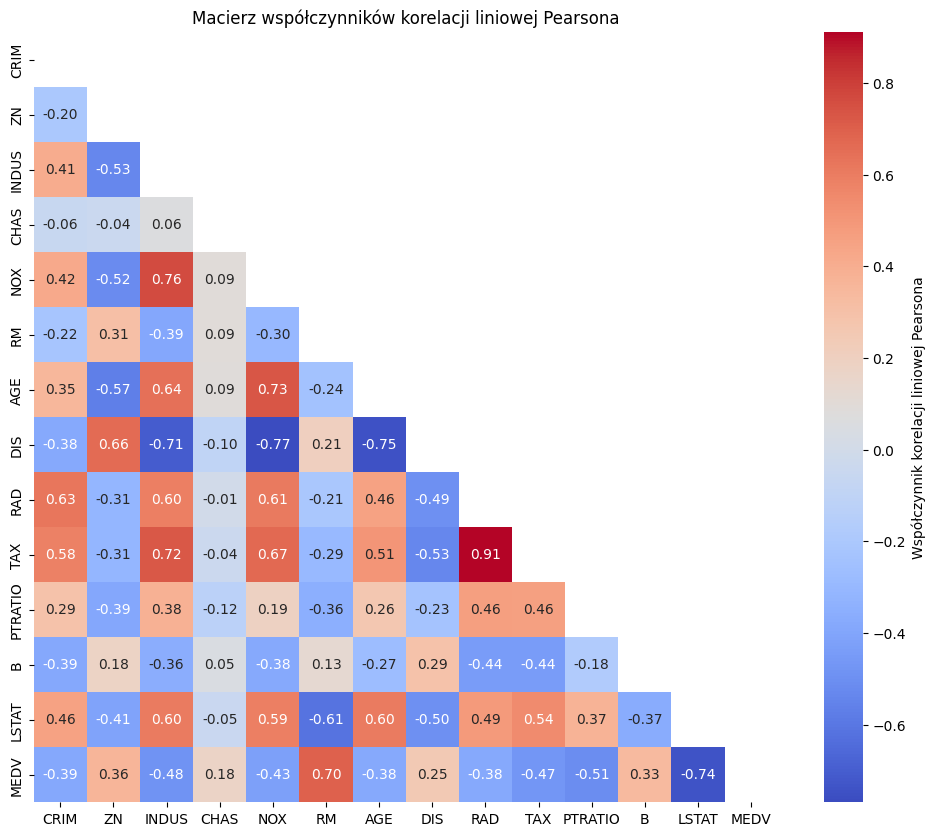

In [255]:
# Exploratory Data Analysis (EDA)

# Podstawowa analiza
print('Kształt danych:')
print(dataset.shape)
print("\n")

print('Braki danych:')
print(dataset.isnull().sum())
print("\n")

print("Podstawowe informacje o zbiorze danych:")
dataset.info()
print("\n")

print("Statystyki opisowe:")
print(dataset.describe())
print("\n")

# # Histogramy
# print("Rozkład cech:")
# plt.figure(figsize=(12,8))
# dataset.hist(bins=20, figsize=(14,10))
# plt.tight_layout()
# plt.show()

# # Boxploty
# print("Boxploty:")
# cols = dataset.columns
# n = len(cols)
# rows = int(np.ceil(n/3))
# plt.figure(figsize=(16, rows * 3))
# for i, col in enumerate(cols, 1):
#     plt.subplot(rows, 3, i)
#     sns.boxplot(y=dataset[col])
#     plt.title(col)
# plt.tight_layout()
# plt.show()

# Analiza rozkładu zmiennej docelowej (MEDV - cena domu)
plt.figure(figsize=(8, 6))
sns.histplot(dataset['MEDV'], kde=True, bins=30)
plt.title('Rozkład Ceny Domów (MEDV)')
plt.xlabel('Cena (MEDV)')
plt.show()

# ---------- Analiza współczynników korelacji liniowej Pearsona ----------
corr = dataset.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # maska dla górnego trójkąta
np.fill_diagonal(corr.values, np.nan)           # usunięcie wartości na przekątnej (by nie pokazywać 1.00)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    cbar_kws={"label": "Współczynnik korelacji liniowej Pearsona"}
)
plt.title('Macierz współczynników korelacji liniowej Pearsona')
plt.show()


Analiza brakujących wartości:  
Zbiór danych Boston Housing jest kompletny. W każdej kolumnie znajduje się dokładnie 506 obserwacji. Oznacza to, że nie musimy stosować imputacji (wypełniania brakujących danych).  

Większość zmiennych ma charakter numeryczny ciągły. Jedynie zmienna CHAS to zmienna binarna, a zmienna RAD jest zmienną numeryczną dyskretną.

Zmienna docelowa MEDV (cena) ma rozkład zbliżony do normalnego, ale z większym skupieniem przy niższych wartościach.

### Analiza współliniowości zmiennych

Korelacja każdej zmiennej z MEDV:
 CRIM      -0.388305
ZN         0.360445
INDUS     -0.483725
CHAS       0.175260
NOX       -0.427321
RM         0.695360
AGE       -0.376955
DIS        0.249929
RAD       -0.381626
TAX       -0.468536
PTRATIO   -0.507787
B          0.333461
LSTAT     -0.737663
MEDV       1.000000
Name: MEDV, dtype: float64

Zmienne słabo skorelowane z MEDV: ['CRIM', 'ZN', 'CHAS', 'NOX', 'AGE', 'DIS', 'RAD', 'B']

Zmienne redundantne (|corr| > 0.7): {'LSTAT', 'TAX'}

Aktualny VIF:
    feature       VIF
0    INDUS  1.284624
1       RM  1.254483
2  PTRATIO  1.244879

Wszystkie zmienne mają VIF poniżej progu. Kończę czyszczenie.

Ostateczny zbiór zmiennych:
 ['INDUS', 'RM', 'PTRATIO', 'MEDV']


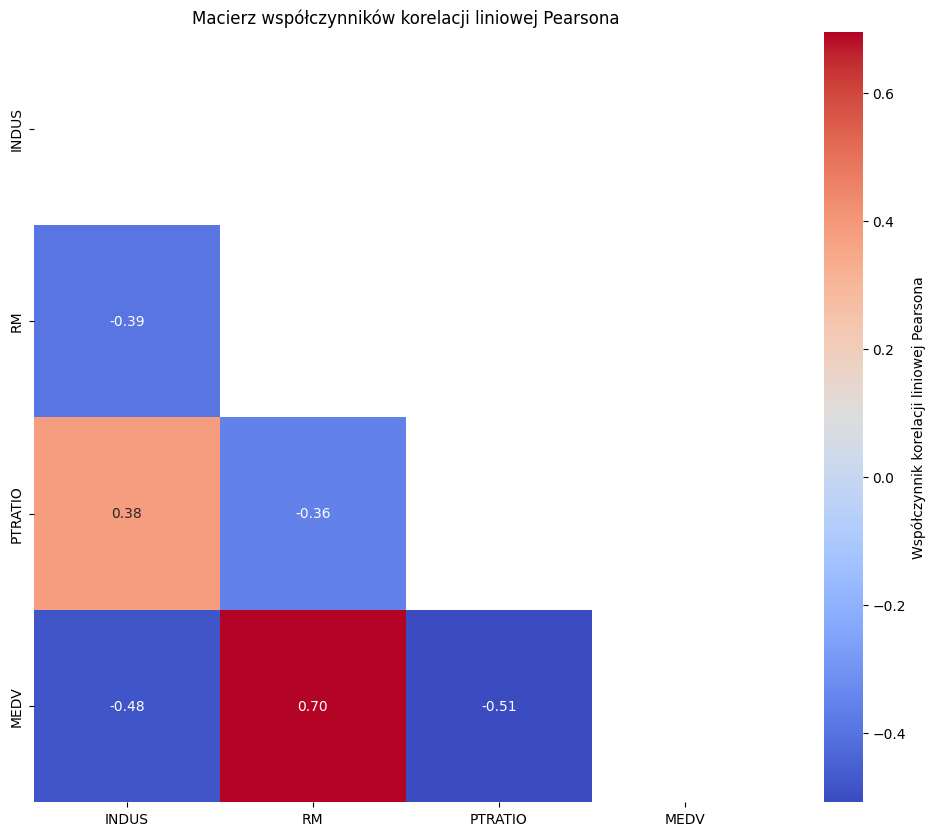

In [239]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


# ---------- Korelacja z MEDV ----------
corr_medv = dataset.corr()['MEDV']
print("Korelacja każdej zmiennej z MEDV:\n", corr_medv)

# Usuwam słabo skorelowane zmienne (|corr| < 0.45)
weak_corr = corr_medv[abs(corr_medv) < 0.45].index.tolist()
if 'MEDV' in weak_corr:
    weak_corr.remove('MEDV')

print("\nZmienne słabo skorelowane z MEDV:", weak_corr)
dataset2 = dataset.drop(columns=weak_corr)


# ---------- Redundantne zmienne wzajemnie skorelowane ----------
corr_matrix = dataset2.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop_corr = set()

for col in upper.columns:
    high_corr = upper.index[upper[col] > 0.7].tolist()
    for other in high_corr:
        corr_col_medv = corr_matrix.loc[col, 'MEDV']
        corr_other_medv = corr_matrix.loc[other, 'MEDV']
        if corr_col_medv >= corr_other_medv:
            to_drop_corr.add(other)
        else:
            to_drop_corr.add(col)

print("\nZmienne redundantne (|corr| > 0.7):", to_drop_corr)
dataset2 = dataset2.drop(columns=list(to_drop_corr))


# ---------- VIF (iteracyjne usuwanie zmiennych z wysokim VIF) ----------
threshold_vif = 5
while True:
    X = dataset2.drop(columns=['MEDV'])
    X_const = sm.add_constant(X)
    vif_df = pd.DataFrame()
    vif_df['feature'] = X.columns
    vif_df['VIF'] = [variance_inflation_factor(X_const.values, i+1) for i in range(len(X.columns))]

    max_vif = vif_df['VIF'].max()
    max_feature = vif_df.loc[vif_df['VIF'].idxmax(), 'feature']

    print("\nAktualny VIF:\n", vif_df)

    if max_vif > threshold_vif:
        print(f"Usuwam zmienną {max_feature} z powodu wysokiego VIF = {max_vif}")
        dataset2 = dataset2.drop(columns=[max_feature])
    else:
        print("\nWszystkie zmienne mają VIF poniżej progu. Kończę czyszczenie.")
        break

# ---------- Wynik końcowy ----------
print("\nOstateczny zbiór zmiennych:\n", dataset2.columns.tolist())


# ---------- Analiza współczynników korelacji liniowej Pearsona ----------
corr = dataset2.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # maska dla górnego trójkąta
np.fill_diagonal(corr.values, np.nan)           # usunięcie wartości na przekątnej (by nie pokazywać 1.00)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    cbar_kws={"label": "Współczynnik korelacji liniowej Pearsona"}
)
plt.title('Macierz współczynników korelacji liniowej Pearsona')
plt.show()



Oczyszczono zbiór cech predykcyjnych z danych słabo skorelowanych ze zmienną docelową (MEDV) oraz z cech wykazujących nadmierną redundancję (współliniowość).Proces ten przeprowadzono w dwóch głównych fazach, które skutecznie zredukowały liczbę cech z 13 do 6, co znacząco przyczyni się do stabilności i lepszej interpretowalności modelu regresji liniowej.
  

- W pierwszym kroku przeanalizowano korelację każdej cechy predykcyjnej ze zmienną docelową MEDV. Zmienne o bezwzględnej korelacji <|0.45| niosą zbyt mało informacji prognostycznej, aby uzasadnić ich włączenie do modelu. Usunięto więc zmienne słabo skorelowane z MEDV: ['CRIM', 'ZN', 'CHAS', 'NOX', 'AGE', 'DIS', 'RAD', 'B'].
  
    
- W drugim, kluczowym kroku skupiono się na eliminacji współliniowości (multikolinearności), czyli sytuacji, w której cechy predykcyjne są silnie skorelowane między sobą. Współliniowość może prowadzić do niestabilnych i trudnych do interpretacji współczynników w modelu regresji liniowej. Zdecydowano o usunięciu jednej zmiennej z każdej pary lub grupy cech, których wzajemna korelacja bezwzględna przekraczała próg >|0.7|. W wyniku tej analizy zidentyfikowano i usunięto następujące zmienne: : ['LSTAT', 'TAX'].


- Po usunięciu cech w obu fazach przeprowadzono weryfikację za pomocą Współczynnika Inflacji Wariancji (VIF), który mierzy, w jakim stopniu wariancja oszacowanych współczynników jest zwiększona z powodu współliniowości. Przyjęto standardowy próg akceptowalności VIF < 5.


Na końcu przeanalizowano macierz współczynników korelacji liniowej Pearsona.  

Ostateczny zbiór cech jest wolny od poważnej współliniowości, co gwarantuje stabilność modelu regresji liniowej oraz wiarygodność interpretacji jego współczynników.
W rezultacie procesu selekcji i redukcji, do końcowej analizy i trenowania modeli wybrano następujący, zoptymalizowany zestaw zmiennych predykcyjnych: ['INDUS', 'RM', 'PTRATIO'].

# Modele dla wszystkich zmiennych

## 3. Podział zbioru danych

In [240]:
# Podział zbioru danych
from sklearn.model_selection import train_test_split

X = dataset.drop('MEDV', axis=1)
y = dataset['MEDV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Dane treningowe: {X_train.shape[0]} rekordów, Dane testowe: {X_test.shape[0]} rekordów")

Dane treningowe: 404 rekordów, Dane testowe: 102 rekordów


## 4. Trenowanie modeli

In [241]:
# Regresja Liniowa
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

# XGBoost
import xgboost as xgb

xg_reg = xgb.XGBRegressor(
    objective='reg:squarederror',
    colsample_bytree=0.3,
    learning_rate=0.1,
    max_depth=5,
    alpha=10,
    n_estimators=10,
    random_state=42
)

xg_reg.fit(X_train, y_train)

XGBRegressor(alpha=10, base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.3, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=10,
             n_jobs=None, ...)

## 5. Optymalizacja hiperparametrów (GridSearchCV)

In [242]:
# Zastosowanie GridSearchCV dla modelu XGBoost
from sklearn.model_selection import train_test_split, GridSearchCV

# Siatka hiperparametrów do przetestowania
params = {
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7],
    'n_estimators': [50, 100, 200]
}

# Definicja modelu
xg_reg2 = xgb.XGBRegressor(objective='reg:squarederror', colsample_bytree=0.3, random_state=42)

# Inicjalizacja GridSearchCV
# Używamy ujemnej średniej kwadratowej błędu jako metryki (im wyższa tym lepsza)
grid = GridSearchCV(
    estimator=xg_reg2,
    param_grid=params,
    cv=5, # każdy model był testowany 5-krotnie (przez walidację krzyżową)
    #scoring='neg_mean_squared_error', # minimalizuje błąd
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

# Dopasowanie Grid Search do danych treningowych
grid.fit(X_train, y_train)

# Wyświetlenie najlepszych wyników
print("\nNajlepszy wynik GridSearchCV dla XGBoost:")
print("Best score: %.4f using params: %s" % (grid.best_score_, grid.best_params_))

# Ostateczny, zoptymalizowany model
xg_reg_opt = grid.best_estimator_  # nadpisanie poprzedniej, bazowej wersji modelu XGBoost

Fitting 5 folds for each of 27 candidates, totalling 135 fits

Najlepszy wynik GridSearchCV dla XGBoost:
Best score: 0.8288 using params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


## 6. Porównanie wyników różnych modeli na zbiorze testowym

In [243]:
# Ewaluacja modeli
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Regresja liniowa
y_pred_lr = lr.predict(X_test)
print('Linear Regression - MSE: ', mean_squared_error(y_test, y_pred_lr))
print('Linear Regression - MAE: ', mean_absolute_error(y_test, y_pred_lr))
print('Linear Regression - R2: ', r2_score(y_test, y_pred_lr))

# XGBoost
y_pred_xg = xg_reg.predict(X_test)
print('XGBoost - MSE: ', mean_squared_error(y_test, y_pred_xg))
print('XGBoost - MAE: ', mean_absolute_error(y_test, y_pred_xg))
print('XGBoost - R2: ', r2_score(y_test, y_pred_xg))

# XGBoost po optymalizacji hiperparametrów (GridSearchCV)
y_pred_xg_opt = xg_reg_opt.predict(X_test)
print('XGBoost po optymalizacji - MSE: ', mean_squared_error(y_test, y_pred_xg_opt))
print('XGBoost po optymalizacji - MAE: ', mean_absolute_error(y_test, y_pred_xg_opt))
print('XGBoost po optymalizacji - R2: ', r2_score(y_test, y_pred_xg_opt))

Linear Regression - MSE:  24.291119474973478
Linear Regression - MAE:  3.189091965887837
Linear Regression - R2:  0.6687594935356326
XGBoost - MSE:  36.41615416345713
XGBoost - MAE:  3.830751441506779
XGBoost - R2:  0.5034191256184913
XGBoost po optymalizacji - MSE:  11.674647025498567
XGBoost po optymalizacji - MAE:  2.274116015901752
XGBoost po optymalizacji - R2:  0.8408012443599786


Na początku modelowanie przeprowadzono na zbiorze ze wszystkimi zmiennymi.  

Model regresji liniowej zakłada liniową zależność między cechami a ceną domu.

Model XGBoost - kolejne drzewa uczone są tak, aby korygować błędy poprzednich.   Parametry mające na celu ograniczenie przeuczenia:  
- colsample_bytree=0.3 (drzewo korzysta z 30% losowych cech)
- learning_rate=0.1 (określa jak szybko model uczy się na błędach; tempo uczenia)
- max_depth=5 (średnia głębokość drzewa; złożoność drzewa)
- alpha=10 (regularyzacja L1 ograniczająca wpływ mniej istotnych cech)
- n_estimators=10 (liczba drzew zastosowana jako punkt wyjścia).

Następnie przeprowadzono optymalizację hiperparamerów, aby odnaleźć zestaw ustawień który maksymalizuje R2 (Współczynnik determinacji R2 mierzy, jaki odsetek całkowitej wariancji zmiennej zależnej (docelowej, np. MEDV) jest wyjaśniany przez model (czyli przez zmienne niezależne/predykcyjne)).

GridSearchCV przetestował wszystkie kombinacje w 5-krotnej walidacji krzyżowej.
Najlepsze wyniki uzyskano dla parametrów ['learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100].

Na podstawie dobranych parametrów zbudowano drugi model XGBoost.  

Modele oceniono na podstawie:  
- MSE (Mean Squared Error) – Średni Błąd Kwadratowy (oblicza średnią z kwadratów różnic między przewidywanymi wartościami a rzeczywistymi wartościami). MSE dąży do minimalizacji. Im niższa wartość MSE, tym lepszy model.  
- MAE (Mean Absolute Error) – Średni Błąd Bezwzględny (MAE oblicza średnią z bezwzględnych różnic między przewidywanymi wartościami a rzeczywistymi wartościami). MAE dąży do minimalizacji. Im niższa wartość MAE, tym lepszy model.  
- R2 (Coefficient of Determination) – Współczynnik Determinacji (R2 mierzy, jaki odsetek całkowitej wariancji zmiennej zależnej jest wyjaśniany przez model (czyli przez zmienne predykcyjne)). Dąży do maksymalizacji. Im bliżej 1, tym lepsze dopasowanie.

Najlepszym modelem okazał się XGBoost po GridSearchCV - najwyższe R2 i najniższe MSE i MAE.

# Modele dla wybranych zmiennych

W kolenym kroku przeprowadzono cały schemat modelowania jeszcze raz, ale dla zbioru danych dataset2, czyli po usunięciu zmiennych, które miały niską korelację ze zmienną objaśnianą i zmiennych które były współliniowe (analiza VIF). Ostateczny zbiór zmiennych: ['INDUS', 'RM', 'PTRATIO'].

In [244]:
# Podział zbioru danych dataset2 do usunięciu zbędnych zmiennych
from sklearn.model_selection import train_test_split

X = dataset2.drop('MEDV', axis=1)
y = dataset2['MEDV']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Dane treningowe: {X_train2.shape[0]} rekordów, Dane testowe: {X_test2.shape[0]} rekordów")

Dane treningowe: 404 rekordów, Dane testowe: 102 rekordów


In [245]:
# Regresja Liniowa
from sklearn.linear_model import LinearRegression

lr2 = LinearRegression()
lr2.fit(X_train2, y_train2)

# XGBoost
import xgboost as xgb

xg_reg2 = xgb.XGBRegressor(
    objective='reg:squarederror',
    colsample_bytree=0.3,
    learning_rate=0.1,
    max_depth=5,
    alpha=10,
    n_estimators=10,
    random_state=42
)

xg_reg2.fit(X_train2, y_train2)

XGBRegressor(alpha=10, base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.3, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=10,
             n_jobs=None, ...)

In [246]:
# Zastosowanie GridSearchCV dla modelu XGBoost
from sklearn.model_selection import train_test_split, GridSearchCV

# Siatka hiperparametrów do przetestowania
params = {
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7],
    'n_estimators': [50, 100, 200]
}

# Definicja modelu
xg_reg2_opt = xgb.XGBRegressor(objective='reg:squarederror', colsample_bytree=0.3, random_state=42)

# Inicjalizacja GridSearchCV
# Używamy ujemnej średniej kwadratowej błędu jako metryki (im wyższa tym lepsza)
grid = GridSearchCV(
    estimator=xg_reg2_opt,
    param_grid=params,
    cv=5, # każdy model był testowany 5-krotnie (przez walidację krzyżową)
    #scoring='neg_mean_squared_error', # minimalizuje błąd
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

# Dopasowanie Grid Search do danych treningowych
grid.fit(X_train2, y_train2)

# Wyświetlenie najlepszych wyników
print("\nNajlepszy wynik GridSearchCV dla XGBoost:")
print("Best score: %.4f using params: %s" % (grid.best_score_, grid.best_params_))

# Ostateczny, zoptymalizowany model
xg_reg_opt2 = grid.best_estimator_  # nadpisanie poprzedniej, bazowej wersji modelu XGBoost

Fitting 5 folds for each of 27 candidates, totalling 135 fits

Najlepszy wynik GridSearchCV dla XGBoost:
Best score: 0.6437 using params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}


In [247]:
# Ewaluacja modeli
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Regresja liniowa
y_pred_lr2 = lr2.predict(X_test2)
print('Linear Regression - MSE: ', mean_squared_error(y_test2, y_pred_lr2))
print('Linear Regression - MAE: ', mean_absolute_error(y_test2, y_pred_lr2))
print('Linear Regression - R2: ', r2_score(y_test2, y_pred_lr2))

# XGBoost
y_pred_xg2 = xg_reg2.predict(X_test2)
print('XGBoost - MSE: ', mean_squared_error(y_test2, y_pred_xg2))
print('XGBoost - MAE: ', mean_absolute_error(y_test2, y_pred_xg2))
print('XGBoost - R2: ', r2_score(y_test2, y_pred_xg2))

# XGBoost po optymalizacji hiperparametrów (GridSearchCV)
y_pred_xg_opt2 = xg_reg_opt2.predict(X_test2)
print('XGBoost po optymalizacji - MSE: ', mean_squared_error(y_test2, y_pred_xg_opt2))
print('XGBoost po optymalizacji - MAE: ', mean_absolute_error(y_test2, y_pred_xg_opt2))
print('XGBoost po optymalizacji - R2: ', r2_score(y_test2, y_pred_xg_opt2))

Linear Regression - MSE:  34.5403234119682
Linear Regression - MAE:  3.658719255783872
Linear Regression - R2:  0.5289984789622015
XGBoost - MSE:  39.11027411878402
XGBoost - MAE:  4.3554970049390604
XGBoost - R2:  0.4666813515773378
XGBoost po optymalizacji - MSE:  23.9322225506353
XGBoost po optymalizacji - MAE:  3.2282708242827773
XGBoost po optymalizacji - R2:  0.6736535124839467


Po usunięciu zmiennych współliniowych wszystkie analizowane parametry modeli (MAE, MSE, R2) uległy pogorszeniu.  
Analiza uzyskanych wyników wskazuje na to, że jakość wszystkich modeli spadła.  

Wniosek:  
Fakt, że metryki (R2, MSE, MAE) pogorszyły się po redukcji cech, mimo że miała ona na celu poprawę modelu (stabilności), oznacza, że utrata informacji przeważa nad korzyściami płynącymi z usunięcia redundancji.  

Najważniejszą przyczyną pogorszenia jest fakt, że cechy, które zostały usunięte w Fazie 1 (|corr| < 0.45 z MEDV), nadal niosły cenną informację, kluczową dla modelu Regresji Liniowej. Pomimo słabej korelacji liniowej parami z MEDV, cechy te mogły działać razem (tworząc interakcje) lub nieliniowo wpływać na cenę. Usunięcie ich znacząco zubożyło model.  

Metoda VIF i korelacji parami w fazie EDA skupiła się na usunięciu redundancji. Chociaż była skuteczna w stworzeniu zbioru o niskim VIF, mogła przypadkowo usunąć kluczowy predyktor.  

Dla Modeli Nieliniowych (XGBoost): Modele drzewiaste, takie jak XGBoost, są odporne na współliniowość i często mogą przetwarzać wszystkie cechy bez problemów. Usuwanie cech dla XGBoost było niepotrzebne i doprowadziło do utraty informacji.

## 7. Sprawdzenie założeń dla regresji liniowej

Założenia dla regresji liniowej:
- 1. liniowa zależność (między zmiennymi objaśniającymi a zmienną objaśnianą)
- 2. rozkład błędów jest normalny
- 3. homoskedastyczość (wariancja błędów jest stała w czasie)

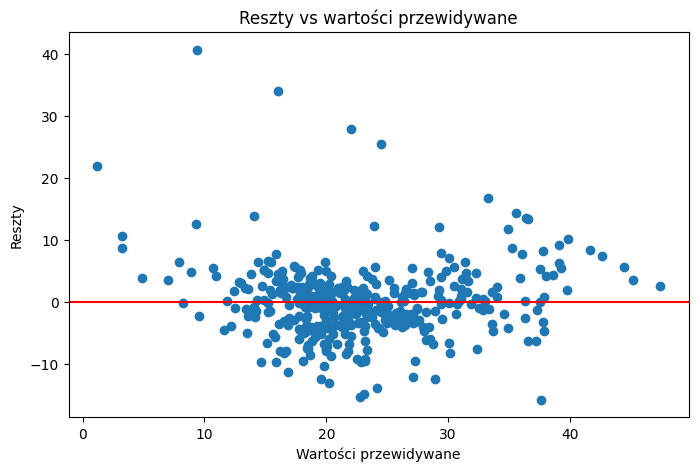

In [249]:
# 1. Liniowa zależność
y_pred2 = lr2.predict(X_train2)
residuals = y_train2 - y_pred2

plt.figure(figsize=(8,5))
plt.scatter(y_pred2, residuals)
plt.axhline(0, color='r')
plt.xlabel('Wartości przewidywane')
plt.ylabel('Reszty')
plt.title('Reszty vs wartości przewidywane')
plt.show()

1. Liniowa zależność:  
Założenie: Związek między cechami a zmienną docelową jest liniowy.  
Założenie nie jest spełnione. Pokazuje to wykres, na którym widać, że reszty nie są skupione wokół prostej. Nie są również równomiernie rozłożone wokół prostej tylko są rozproszone, szczególnie dla niższych wartości.

3. Homoskedastyczność:  
Założenie: Wariancja reszt jest stała dla wszystkich przewidywanych wartości.
Założenie nie jest spełnione. Rozrzut reszt jest wysoki dla niskich przewidywanych cen i wyraźnie maleje dla wysokich przewidywanych cen.

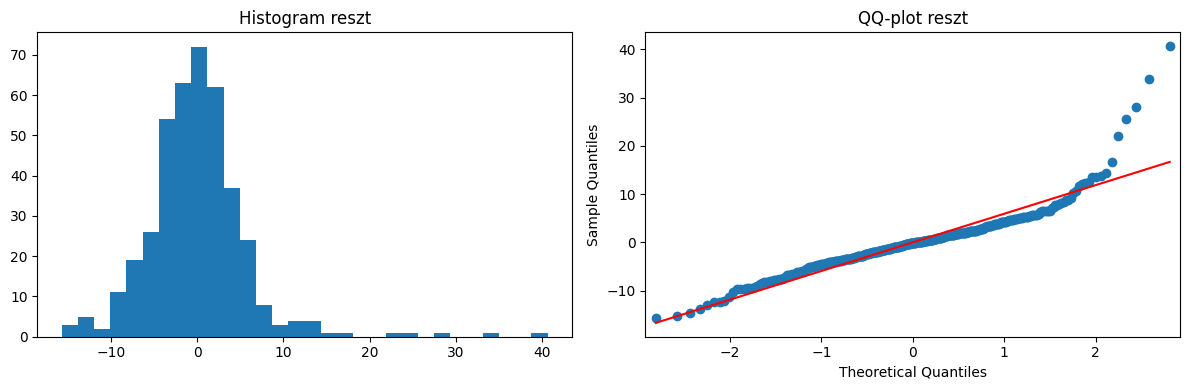


--- Test Shapiro-Wilka dla reszt (train) ---
statistic= 0.8816436622295001 p-value= 4.6039321730188795e-17


In [251]:
# 2. Normalność reszt - histogram + QQ plot + test Shapiro
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(residuals, bins=30)
plt.title('Histogram reszt')


plt.subplot(1,2,2)
sm.qqplot(residuals, line='s', ax=plt.gca())
plt.title('QQ-plot reszt')
plt.tight_layout()
plt.show()


shapiro_test = stats.shapiro(residuals.sample(min(len(residuals),5000), random_state=42))
print('\n--- Test Shapiro-Wilka dla reszt (train) ---')
print('statistic=', shapiro_test.statistic, 'p-value=', shapiro_test.pvalue)

2. Normalność Rozkładu Reszt  
Założenie: Reszty modelu powinny mieć rozkład normalny ze średnią bliską zeru.  

Histogram reszt pokazuje że rozkład błędów jest w przybliżeniu normalny, jednak ma po prawej stronie długi ogon, a Q-Q Plot pokazuje punkty odchylające się od idealnej linii prostej na krańcach rozkładu.

Test Shapiro-Wilka: zwraca niską wartość p (p < 0.05). Odrzucamy hipotezę zerową o normalności, co oznacza, że rozkład reszt nie jest normalny.

Założenie 2. dla regresji liniowej NIE zostało spełnione.

### Wnioski

Model Regresji Liniowej na zredukowanym zbiorze cech nie spełnia założeń dla regresji liniowej: liniowości, homoskedastyczności i normalności reszt.

### Rekomendowane Działania
- Transformacja Logarytmiczna: transformacja logarytmiczna zmiennej docelowej (MEDV). Transformacja ta często łagodzi problemy normalności i heteroskedastyczności.
- Użycie Modeli Nieliniowych: Potwierdza się celowość użycia modelu XGBoost. Modele te, jako modele nieliniowe, nie wymagają spełnienia tych założeń, stąd ich znacznie lepsza wydajność (R2 = 0.67) w porównaniu do Regresji Liniowej (R2 = 0.52) na tym samym zredukowanym zbiorze cech.

## Podsumowanie
1. Wydajność Modeli (XGBoost vs. Regresja Liniowa)  

Kluczowym wnioskiem z ewaluacji jest zdecydowana przewaga modeli nieliniowych nad Regresją Liniową.  
- XGBoost osiągnął najlepsze wyniki: Model XGBoost wykazał znacznie większą moc predykcyjną (R2 = 0.6730 na zredukowanym zbiorze) w porównaniu do Regresji Liniowej na tym samym zbiorze (R2 = 0.5290). Potwierdza to, że zależności w cenach domów są silnie nieliniowe i model ensemble lepiej je uchwytuje.  
- Optymalizacja hiperparametrów za pomocą GridSearchCV jest niezbędna, ponieważ pozwala na osiągnięcie maksymalnej wydajności modelu XGBoost.  
  
2. Wpływ Redukcji Cech (Dylemat: Stabilność vs. Dokładność)   

Proces selekcji cech (filtracja słabo skorelowanych cech i eliminacja współliniowości za pomocą VIF) doprowadził do powstania bardzo stabilnego zestawu cech (INDUS, RM, PTRATIO), ale wiązał się z wysokim kosztem informacyjnym.  
- Redukcja cech wpłynęła negatywnie na dokładność: Model Regresji Liniowej trenowany na zredukowanym zbiorze cech (R2 = 0.53) jest znacznie gorszy niż ten trenowany na wszystkich 13 oryginalnych cechach (R2 = 0.69).  
- Wniosek: Pomimo problemów ze współliniowością, pełny zestaw cech zawierał unikatowe i istotne sygnały prognostyczne (np. silne predyktory, które mogły zostać usunięte jako redundantne w procesie VIF), które były kluczowe dla minimalizacji błędu, zwłaszcza dla modelu liniowego.  

3. Analiza Założeń Regresji Liniowej  

Analiza założeń dla modelu liniowego wskazała na poważne problemy, które wyjaśniają, dlaczego Regresja Liniowa ustępuje modelom nieliniowym:
- Brak Homoskedastyczności (Naruszenie): Wariancja reszt nie jest stała, lecz rośnie wraz ze spadkiem przewidywanej ceny (Heteroskedastyczność). Oznacza to, że predykcje dla tańszych domów są mniej wiarygodne i obarczone większym, niestabilnym błędem.
- Brak Normalności Reszt (Naruszenie): Rozkład reszt nie jest idealnie normalny.  

Ze względu na naruszenie kluczowych założeń, Regresja Liniowa, mimo osiągnięcia przyzwoitego R2 na pełnym zbiorze cech, jest niestabilna teoretycznie. Wyniki i testy statystyczne oparte na tym modelu mogą być nieprawidłowe lub obciążone.

Redukcja cech, choć poprawiła stabilność, obniżyła dokładność modeli. Lepszą zdolność predykcyjną osiągnęły modele na pełnym zestawie 13 cech.

Model XGBoost zoptymalizowany przez GridSearchCV jest modelem technicznie lepszym, ponieważ oferuje wysoką dokładność (R2 = 0.67) bez obciążenia naruszeniami założeń, które dyskwalifikują Regresję Liniową.  
Jeśli celem jest najwyższa dokładność predykcyjna, należy trenować model XGBoost na pełnym zbiorze 13 cech (z pominięciem redukcji) i poddać go dalszej optymalizacji.